<a href="https://colab.research.google.com/github/Vaneelins/Vaneelins/blob/main/Climatologia_Brasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#instalar a biblioteca netcdf4
!pip install xarray netCDF4 numpy matplotlib
!pip install cartopy xarray netCDF4 matplotlib
!apt-get install -qq libproj-dev proj-data proj-bin libgeos-dev
#chamar as bibliotecas para calcular as médias mensais
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive #para logar no drive
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib as mpl # Importação necessária para o colormap

In [ ]:
# Montar o Google Drive
drive.mount('/content/drive')

# Carregar o arquivo NetCDF
caminho_arquivo = '/content/drive/MyDrive/TCC2/Arquivotcc/1991-2020-SulAmerica.nc'
ds = xr.open_dataset(caminho_arquivo)
tcslw = ds['tcslw']

# Abrir o dataset
ds = xr.open_dataset(caminho_arquivo)
tcslw = ds['tcslw']
#checar variável
#print(ds)

Mounted at /content/drive


In [ ]:
ds

<xarray.Dataset> Size: 93MB
Dimensions:     (valid_time: 360, latitude: 269, longitude: 241)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01T06:00:00 ... 2020-...
  * latitude    (latitude) float64 2kB 12.0 11.75 11.5 ... -54.5 -54.75 -55.0
  * longitude   (longitude) float64 2kB -80.0 -79.75 -79.5 ... -20.25 -20.0
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Data variables:
    tcslw       (valid_time, latitude, longitude) float32 93MB 0.0004196 ... ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [ ]:
print(media_anual.min().values)
print(media_anual.max().values)

0.00014308294339571148
0.1964384764432907


In [ ]:
print(media_anual.min().values)
print(media_anual.max().values)

0.00014308294339571148
0.1964384764432907


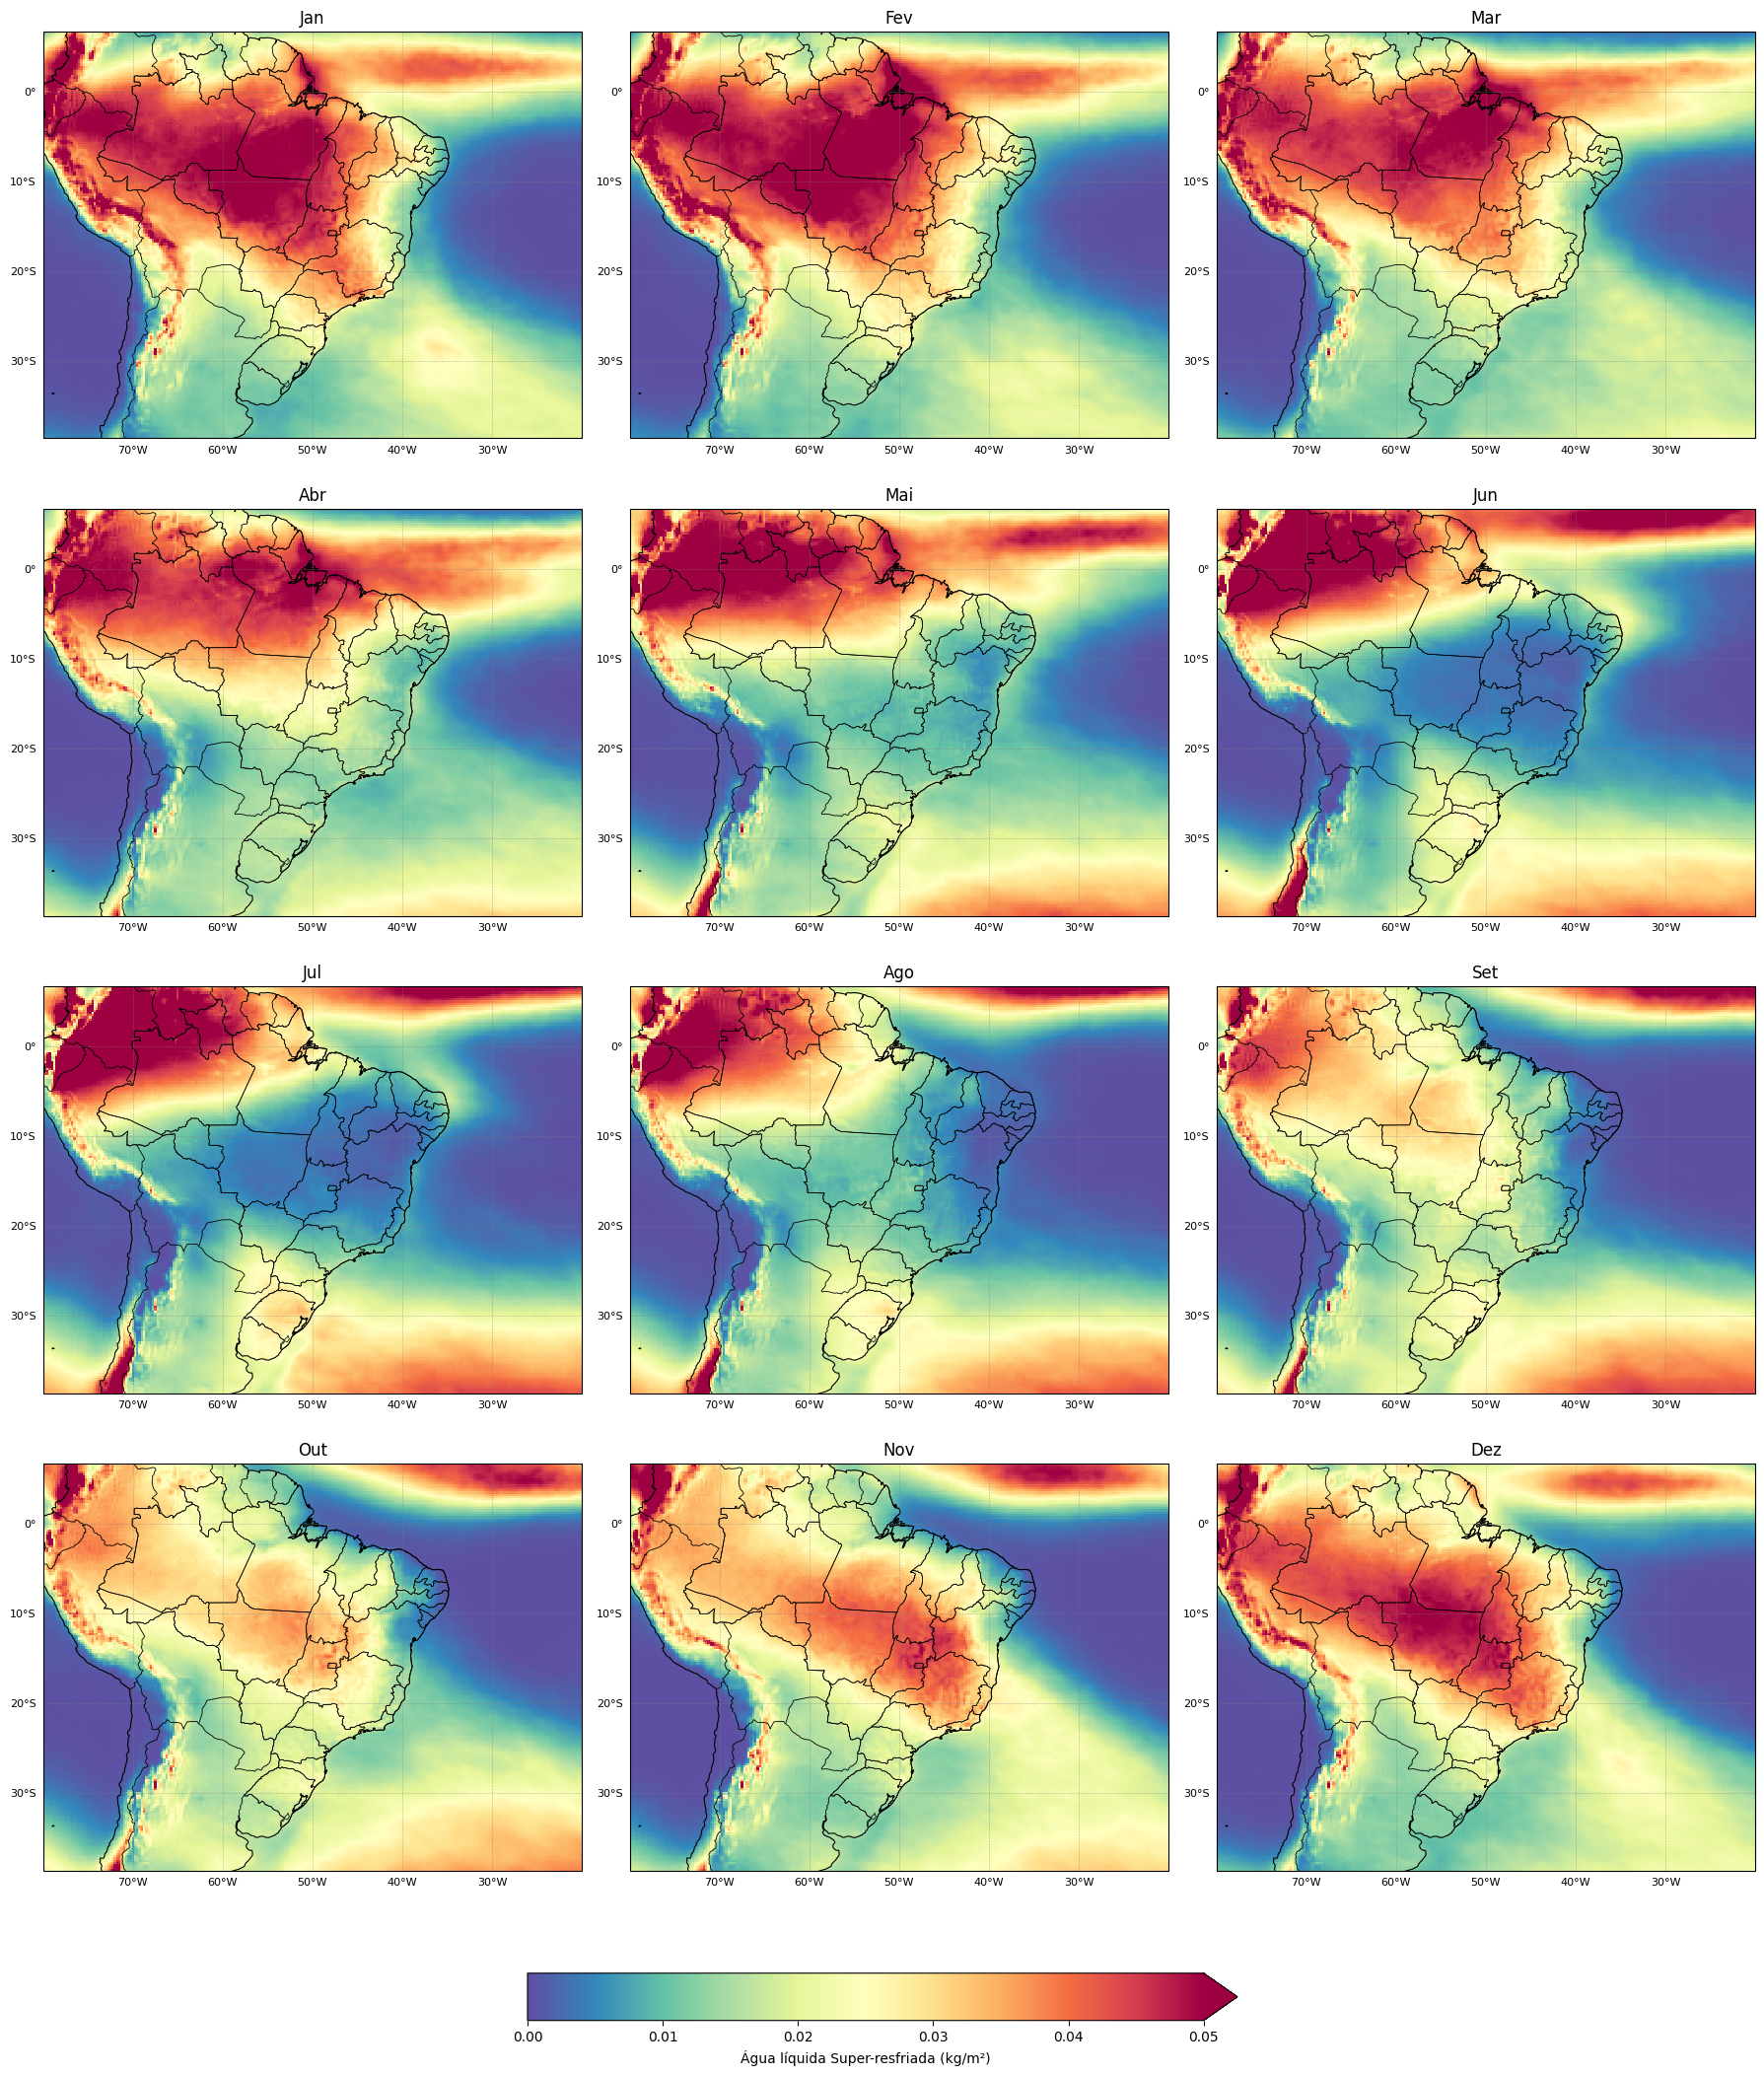

In [ ]:
# Supondo que 'tcslw' é um DataArray (Mantenha seu código original, mas garantindo que vmin/vmax seja respeitado)
# Calcular médias mensais
media_mensal = tcslw.groupby('valid_time.month').mean(dim='valid_time')

# Definir limites da escala de cores (AJUSTADO PARA 0.06)
vmin = 0
vmax = 0.05 # Ajustado para o valor solicitado de 0.06

# Plotar 12 mapas mensais
fig, axs = plt.subplots(4, 3, figsize=(18, 24), subplot_kw={'projection': ccrs.PlateCarree()})
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
fig.subplots_adjust(top=0.92) # Move o conteúdo um pouco para baixo
fig.suptitle('', fontsize=16, fontweight='bold', y=0.95)

# Lista para armazenar o objeto de mapeamento de cores (necessário para o colorbar)
plot_handle = None

for i, ax in enumerate(axs.flat):
    # Usar pcolormesh diretamente para maior controle sobre vmin/vmax e colorbar
    # e para garantir que o objeto de mapeamento de cores seja salvo.
    p = ax.pcolormesh(
        media_mensal.longitude,
        media_mensal.latitude,
        media_mensal.sel(month=i+1), # Seleção correta do mês
        transform=ccrs.PlateCarree(),
        cmap='Spectral_r',
        vmin=vmin,
        vmax=vmax
    )

    # Salva o objeto de mapeamento de cores do último plot.
    # Como todos usam o mesmo vmin/vmax, qualquer um serve.
    if plot_handle is None:
        plot_handle = p

    ax.set_title(meses[i], fontsize=12)
    ax.set_extent([-80, -20, -35, 6])

    # Adicionar features do mapa
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle='-', linewidth=0.6)
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)

    # Gridlines com labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

# --- Ajuste do Colorbar ---
# Garantir que plot_handle tenha o objeto Colormesh para criar o colorbar
if plot_handle is not None:
    plt.tight_layout(rect=[0, 0.05, 1, 0.9]) # Deixa espaço embaixo para o colorbar (ajustado o topo para 0.9)

    # Adicionar barra de cores horizontal fora dos subplots
    cbar_ax = fig.add_axes([0.3, 0.02, 0.4, 0.02]) # Posicionado centralizado: [left, bottom, width, height]
    cb = fig.colorbar(plot_handle, cax=cbar_ax, orientation='horizontal', extend='max')
    cb.set_label('Água líquida Super-resfriada (kg/m²)')

plt.show()

/tmp/ipython-input-2442747509.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  original_cmap = plt.cm.get_cmap('Spectral_r').copy()


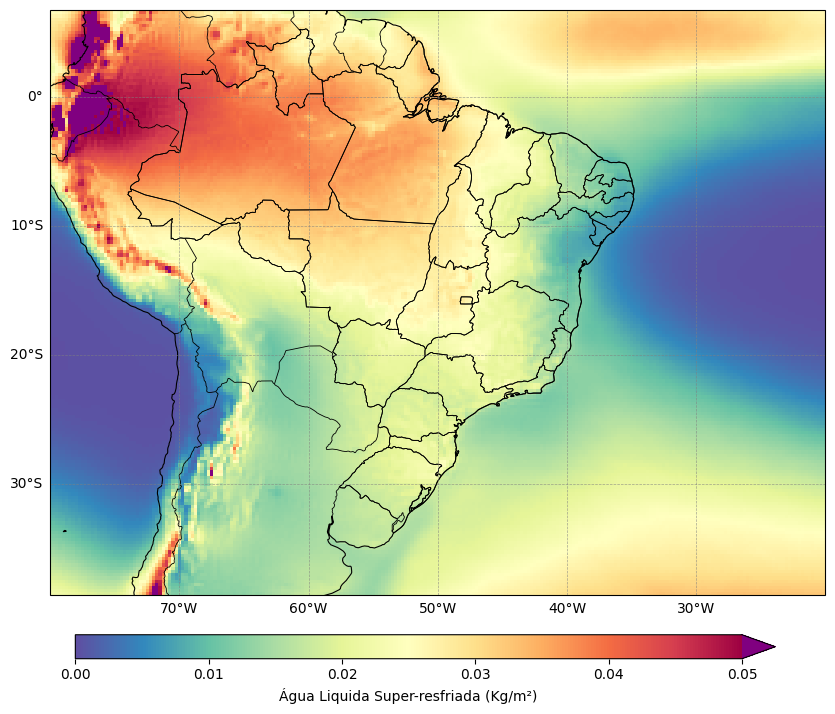

In [ ]:
# Calcular a média anual no tempo todo
media_anual = tcslw.mean(dim='valid_time')

# Definir limites da escala de cores para o PLOT (Corte visual no mapa)
vmin = 0.0
vmax = 0.05 # Valores acima de 0.05 serão "estourados"

# Criar figura
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- INÍCIO DAS MUDANÇAS PARA CORES DE ESTOURO ---

# 1. Obter o colormap original
original_cmap = plt.cm.get_cmap('Spectral_r').copy()

# 2. Definir a cor para os valores "estourados" (acima de vmax)
# Escolha uma cor que se destaque, por exemplo, vermelho escuro, roxo, magenta, etc.
# Pode ser um nome de cor ('red', 'magenta'), um código HEX ('#8B0000'), ou um RGB (0.5, 0, 0, 1)
over_color = 'purple' # Ou 'darkred', 'magenta', '#FF00FF'

# 3. Aplicar a cor de "estouro" ao colormap
original_cmap.set_over(over_color)

# --- FIM DAS MUDANÇAS PARA CORES DE ESTOURO ---

# Plotar SEM a barra de cores automática (add_colorbar=False)
# Usar o colormap modificado
p = media_anual.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=original_cmap, # Usar o colormap modificado aqui
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False # Remove a barra de cores automática
)

# Adicionar gridlines com labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Adicionar feições geográficas
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle='-', linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.6)
ax.set_title('', fontsize=14)
ax.set_extent([-80, -20, -35, 6]) # Ajuste do domínio

# --- CRIAÇÃO DO COLORBAR CUSTOMIZADO ---
# Não precisamos de ScalarMappable complexo aqui, pois o 'p' já carrega o cmap com 'set_over'
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03]) # [left, bottom, width, height]

# O argumento 'extend="max"' fará com que o colorbar exiba a cor 'over_color'
cb = fig.colorbar(
    p, # Usamos 'p' (o objeto do plot) que já tem o colormap modificado
    cax=cbar_ax,
    orientation='horizontal',
    extend='max' # Isso é crucial para mostrar a cor 'over_color'
)

# Seus ticks desejados (ajuste se necessário)
desired_ticks = [0, 0.01, 0.02, 0.03, 0.04, 0.05] # Note que o último tick é vmax

cb.set_ticks(desired_ticks)
cb.set_label('Água Liquida Super-resfriada (Kg/m²)')

plt.show()

In [ ]:
!pip install geopandas regionmask shapely

import geopandas as gpd
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import regionmask
from shapely.geometry import Polygon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 59.0 MB/s eta 0:00:00


In [ ]:
#para  calcular apenas os valores do Brasil usando malha

import geopandas as gpd

#Ajuste o nome do seu arquivo da malha aqui!
gdf = gpd.read_file('/content/drive/MyDrive/TCC2/Arquivotcc/malhas_uf/BR_Pais_2024.shp')



In [ ]:
# Reprojetar para lat/lon se necessário
gdf = gdf.to_crs("EPSG:4326")

# Criar uma máscara raster com base na geometria
lon = ds.longitude.values
lat = ds.latitude.values
lon_grid, lat_grid = np.meshgrid(lon, lat)

In [ ]:
from shapely.geometry import Point
import geopandas as gpd

# Flatten the grid
points = [Point(xy) for xy in zip(lon_grid.ravel(), lat_grid.ravel())]
gdf_points = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")

In [ ]:
#--- CONTINUAÇÃO DO SEU CÓDIGO APÓS CRIAR gdf_points ---

# 1. Aplicar a junção espacial (Spatial Join)
# Identifica quais pontos (gdf_points) caem DENTRO da geometria do Brasil (gdf).
# Usamos 'inner' para manter apenas os pontos que estão DENTRO do Brasil.
print("Aplicando junção espacial para identificar pontos dentro do Brasil...")
tcslw_masked_points = gpd.sjoin(gdf_points, gdf, how="inner", predicate="within")

# A junção espacial retorna um DataFrame apenas com os pontos dentro do Brasil.
# As colunas 'index_right', 'valid_time', 'longitude', 'latitude' serão úteis.
# No entanto, vamos usar o índice original para mapear de volta aos seus dados.

# 2. Mapear os pontos de volta à grade original (DataArray)
# O DataFrame de pontos tem o mesmo tamanho da grade 2D original (lon_grid.ravel()).

# Criar uma série de booleanos (True = Dentro do Brasil, False = Fora)
# O array original 'points' tem (N*M) elementos. O 'tcslw_masked_points' tem menos.

# Para simplificar, vamos criar a coluna 'is_in_brazil' na ordem original:
is_in_brazil = np.zeros(len(points), dtype=bool)
# O índice do DataFrame 'gdf_points' corresponde à posição 1D da grade original.
# O índice retornado pelo sjoin são os índices dos pontos que CAÍRAM DENTRO.
original_indices = tcslw_masked_points.index.values.astype(int)

# 3. Empilhar e Limpar o DataFrame final (Tcslw)
# Converter o DataArray original (tcslw) para um DataFrame 1D (stack)
tcslw_df = tcslw.stack(space=['longitude', 'latitude']).to_dataframe(name='Tcslw').reset_index()

# Filtrar o DataFrame Xarray usando os índices de pontos DENTRO do Brasil
# Isso é um pouco mais complexo porque você usou GeoPandas sem manter o índice original do Xarray.
# Solução: Use as coordenadas (lat/lon) dos pontos válidos para filtrar o DataFrame Xarray.

# Para evitar bugs complexos de mapeamento, vamos garantir que só os pontos dentro do Brasil permaneçam
valid_lon = tcslw_masked_points['geometry'].x.values
valid_lat = tcslw_masked_points['geometry'].y.values

# Recriar o DataArray com NaNs fora da máscara (Mascaramento final)
# NOTA: Devido à complexidade de usar GeoPandas e voltar ao Xarray,
# a forma mais eficiente é *reutilizar* as coordenadas válidas:

# Passo 3.1: Criar um identificador de ponto no df original
tcslw_df['lon_lat'] = tcslw_df['longitude'].round(6).astype(str) + '_' + tcslw_df['latitude'].round(6).astype(str)
tcslw_masked_points['lon_lat'] = tcslw_masked_points['geometry'].x.round(6).astype(str) + '_' + tcslw_masked_points['geometry'].y.round(6).astype(str)

# Passo 3.2: Filtrar o DataFrame Xarray para manter apenas os pontos que estão no GeoDataFrame clipado
tcslw_br_df = tcslw_df[tcslw_df['lon_lat'].isin(tcslw_masked_points['lon_lat'])].copy()
tcslw_br_df.drop(columns=['lon_lat'], inplace=True)
tcslw_br_df = tcslw_br_df.dropna(subset=['Tcslw']).reset_index()


# 4. Criar a coluna 'month' (necessária para o Box Plot)
tcslw_br_df['month'] = tcslw_br_df['valid_time'].dt.month
print(f"DataFrame para Box Plot criado. Total de pontos no Brasil: {len(tcslw_br_df)}")

Aplicando junção espacial para identificar pontos dentro do Brasil...
DataFrame para Box Plot criado. Total de pontos no Brasil: 4092840


In [ ]:
# --- PARTE 2: CÁLCULO E PLOTAGEM DO BOX PLOT ---

# Agrupar por mês
climatology_groups = tcslw_br_df.groupby('month')['Tcslw']

# Calcular Média e Desvio Padrão Mensal
media_mensal = climatology_groups.mean()
std_mensal = climatology_groups.std()
dp_sazonal_medio = std_mensal.mean()




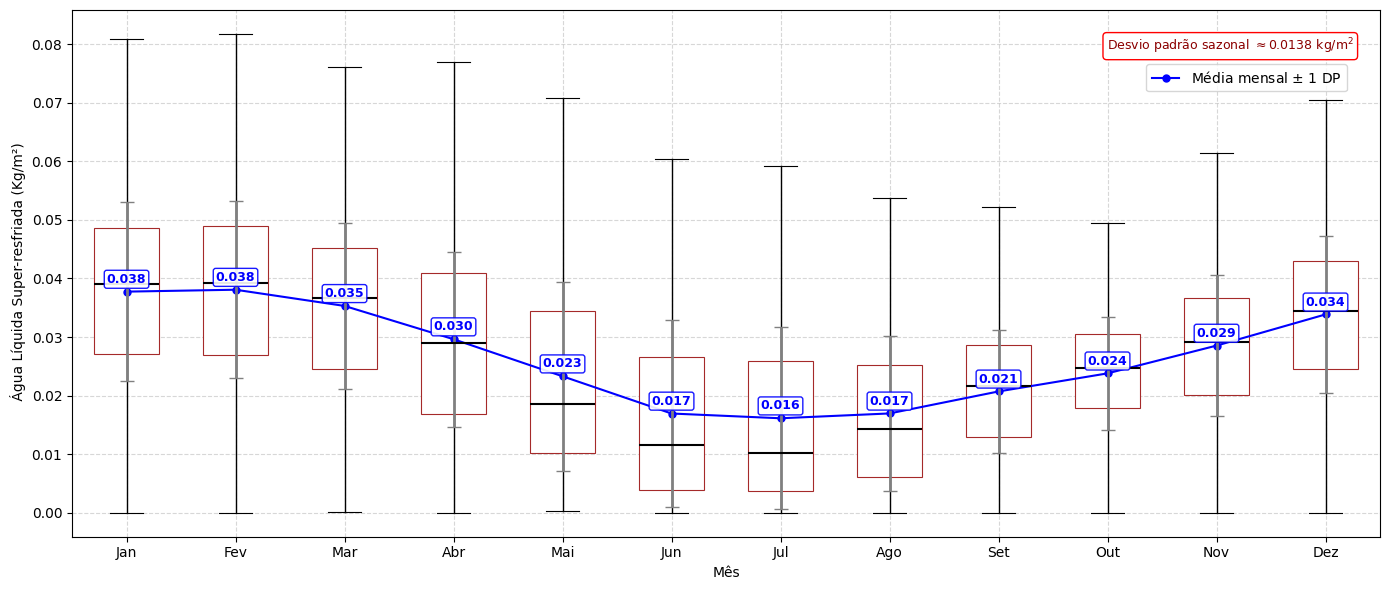

In [ ]:
# --- PARTE 3: PLOTAGEM DO GRÁFICO COM ESTILO SC ---

meses_labels = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
fig, ax = plt.subplots(figsize=(14, 6)) # Aumentamos um pouco o tamanho (14x6)

# Preparar os dados para o Matplotlib (lista de arrays para cada mês)
data_for_boxplot = [tcslw_br_df[tcslw_br_df['month'] == m]['Tcslw'].values for m in range(1, 13)]

# 1. Plotar o Box Plot usando ax.boxplot()
# ESTÉTICA DE SC: facecolor='white', color='brown', mediana 'black', showfliers=False
boxplot = ax.boxplot(
    data_for_boxplot,
    positions=np.arange(1, 13),
    patch_artist=True,
    widths=0.6,
    showfliers=False, # Exclui os outliers

    # ESTILOS IGUAIS A SC
    boxprops=dict(facecolor='white', edgecolor='brown', linewidth=0.8),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black', linestyle='-'),
    capprops=dict(color='black', linewidth=0.8)
)


# 2. Plotar a linha da Média Mensal (Azul)
ax.plot(
    media_mensal.index,
    media_mensal.values,
    marker='o',
    color='blue',
    linestyle='-',
    linewidth=1.5,
    markersize=5,
    label='Média mensal $\\pm$ 1 DP'
)

# 3. Adicionar a barra de erro (Desvio Padrão - ± 1 DP)
# ESTÉTICA DE SC: ecolor='gray', elinewidth=2, capsize=5
ax.errorbar(
    x=media_mensal.index,
    y=media_mensal.values,
    yerr=std_mensal.values,
    fmt='none',
    ecolor='gray', # Corrigido para 'gray'
    elinewidth=2, # Aumenta a espessura da linha de erro
    capsize=5, # Aumenta o tamanho das "tampas"
    linewidth=0.8
)

# 4. Adicionar os valores da Média Mensal (etiquetas)
for i, (mes, media) in enumerate(media_mensal.items()):
    # Posiciona 0.001 acima do ponto da média para centralizar
    ax.text(mes, media + 0.001, f'{media:.3f}',
            ha='center',
            va='bottom',
            color='blue',
            fontsize=9,
            weight='bold', # Adicionado negrito (bold)
            # CAIXA PERSONALIZADA (estilo de SC)
            bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.2', alpha=0.9))


# --- PARTE 4: CONFIGURAÇÃO FINAL E DECORAÇÕES ---

ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(meses_labels)

# Título e rótulos
ax.set_title('', fontsize=14, weight='bold') # Título em negrito
ax.set_xlabel('Mês')
ax.set_ylabel(' Água Líquida Super-resfriada (Kg/m²)')

# Desvio Padrão Sazonal (Texto no canto superior)
# ESTÉTICA DE SC: bbox com facecolor='white' e edgecolor='red'
ax.text(0.98, 0.95,
        r'Desvio padrão sazonal $\approx {dp_sazonal_medio:.4f}\ \text{{kg/m}}^2$'.format(dp_sazonal_medio=dp_sazonal_medio),
        transform=ax.transAxes,
        fontsize=9,
        color='darkred', # Corrigido para darkred, como no exemplo
        horizontalalignment='right', # Corrigido para 'right'
        verticalalignment='top', # Corrigido para 'top'
        bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3')) # Estilo de caixa

ax.legend(
    # Define que o canto superior direito da caixa da legenda será o ponto de ancoragem
    loc='upper right',
    # Ancoramos a legenda em X=0.98 (quase no limite direito) e Y=0.88 (abaixo da caixa do DP)
    bbox_to_anchor=(0.98, 0.91),
    frameon=True,
    fontsize=10
)
ax.grid(True, linestyle='--', alpha=0.5) # Corrigido para alpha=0.5

plt.tight_layout()
plt.show()

In [ ]:
# Assume que 'climatology_groups' já foi definido:
# climatology_groups = tcslw_br_df.groupby('month')['Tcslw']

# --- NOVO CÁLCULO ---
# Calcular o valor mínimo para cada mês
minimo_mensal = climatology_groups.min()

print("Valores Mínimos Mensais (30 anos):")
print(minimo_mensal)

Valores Mínimos Mensais (30 anos):
month
1     0.000000
2     0.000015
3     0.000111
4     0.000000
5     0.000282
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.000000
11    0.000000
12    0.000000
Name: Tcslw, dtype: float32


In [ ]:
# Certifique-se de que a coluna 'valid_time' é o índice para facilitar o agrupamento
tcslw_br_df_indexed = tcslw_br_df.set_index('valid_time')

# 1. Agrupar por ano e calcular a média (tendência)
# 'Tcslw' é a variável que contém os valores de água super-resfriada.
# O .mean() garante que temos um único valor médio para cada ano.
tendencia_anual = tcslw_br_df_indexed.groupby(pd.Grouper(freq='YE'))['Tcslw'].mean()

# 2. Calcular a tendência linear (Opcional, mas útil para mostrar a direção da mudança)
from scipy import stats
anos = np.arange(len(tendencia_anual))
slope, intercept, r_value, p_value, std_err = stats.linregress(anos, tendencia_anual.values)

# Linha de regressão
linha_tendencia = intercept + slope * anos

print(f"Taxa de tendência anual: {slope*1000:.4f} x 10^-3 kg/m² por ano.")

Taxa de tendência anual: -0.0588 x 10^-3 kg/m² por ano.


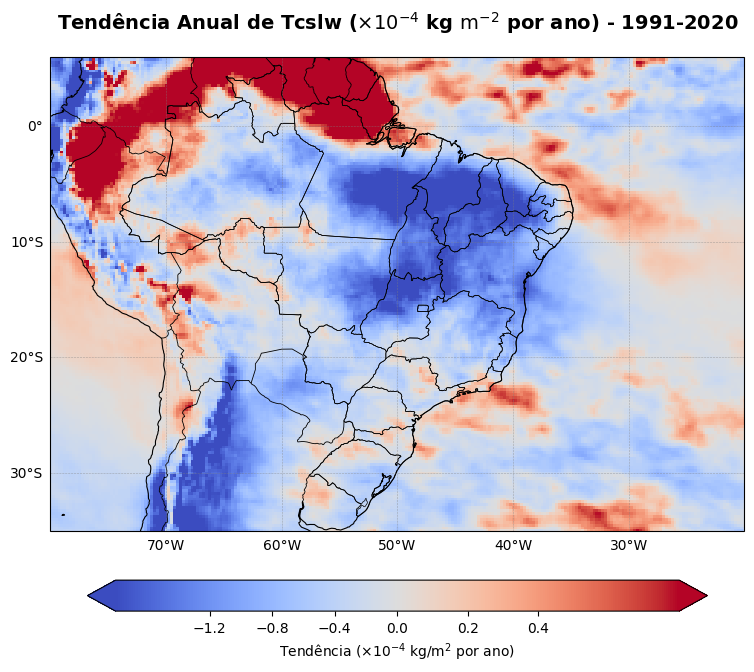

In [ ]:
import matplotlib.colors as mcolors

# --- 1. CONFIGURAÇÃO DE DOMÍNIO E RECORTE (Mantido) ---

# Definir o domínio de interesse (Bounding Box: Longitude -80 a -20, Latitude -35 a 6)
min_lon, max_lon = -80, -20
min_lat, max_lat = -35, 6

# Recortar o DataArray para o domínio especificado
tcslw_recorte = tcslw.sel(
    longitude=slice(min_lon, max_lon),
    latitude=slice(max_lat, min_lat)
)

# --- 2. CÁLCULO DA TENDÊNCIA LINEAR POR PIXEL (Série Anual) ---

# 2.1. Calcular a média anual (Resample)
tcslw_anual_mean = tcslw_recorte.resample(valid_time='YE').mean(dim='valid_time', skipna=True)

# 2.2. Criar a variável de tempo em anos (x)
time_in_years = np.arange(len(tcslw_anual_mean['valid_time']))

# 2.3. Definir a função para regressão (calcula o slope anual)
def calculate_slope(y, x):
    """Calcula a inclinação (slope) da regressão linear, pulando NaNs."""
    finite_indices = np.isfinite(y) & np.isfinite(x)
    if finite_indices.sum() < 2:
        return np.nan
    # Retorna o coeficiente angular (slope)
    return stats.linregress(x[finite_indices], y[finite_indices])[0]

# 2.4. Aplicar a Regressão Linear Anual
slope_anual = xr.apply_ufunc(
    calculate_slope,
    tcslw_anual_mean,
    time_in_years,
    input_core_dims=[['valid_time'], ['valid_time']],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float]
).compute()

# --- FATOR DE ESCALA E LIMITES DE COR ---

# Multiplicamos o slope anual por 10^4 para melhor apresentação dos números
slope_scaled = slope_anual * 10**4

# Limites de cor para a NOVA ESCALA (x 10^-4 kg/m² por ano)
vmin_plot = -1.8 # ~ -0.0001337 * 10^4
vmax_plot = 0.8  # ~ 0.0000435 * 10^4

# Definir a normalização para centralizar o colormap no zero (ponto branco)
norm = mcolors.TwoSlopeNorm(vmin=vmin_plot, vcenter=0., vmax=vmax_plot)


# --- 3. PLOTAGEM DO MAPA DE TENDÊNCIA ---

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotar a tendência (valores escalados)
p = ax.pcolormesh(
    slope_scaled.longitude,
    slope_scaled.latitude,
    slope_scaled.values,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    norm=norm, # Aplica a normalização para centralizar o zero
    # O argumento 'extend' foi removido daqui
)

# Adicionar Feições Geográficas (CORRIGIDO)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle='-', linewidth=0.6)
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5)

# Gridlines com labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Título (Atualizado para x 10^-4)
ax.set_title(r'Tendência Anual de Tcslw ($\times 10^{{-4}}$ kg $\mathrm{m^{-2}}$ por ano) - 1991-2020',
             fontsize=14, fontweight='bold', pad=20)


# --- 4. CONFIGURAÇÃO DO COLORBAR COM ZERO EXPLÍCITO ---

# Definir os ticks para a nova escala (incluindo o 0.0)
custom_ticks = np.array([-1.2, -0.8, -0.4, 0.0, 0.2, 0.4])

# Barra de cores (com extend='both' para as pontinhas)
cbar = fig.colorbar(p, ax=ax, orientation='horizontal', pad=0.08, shrink=0.8,
                    extend='both',
                    ticks=custom_ticks)

# Rótulo (Atualizado para x 10^-4)
cbar.set_label(r'Tendência ($\times 10^{{-4}}\ \mathrm{kg/m}^2$ por ano)')

plt.show()